In [49]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [112]:
df = pd.read_csv("VideoGamesSales.csv")

In [113]:
#df = df[df.duplicated()]

In [114]:
df.shape

(5909, 15)

In [115]:
df = df.drop_duplicates()

In [116]:
df.shape

(5893, 15)

In [117]:
df["Region"] = df["Region"].fillna("North")
df["NA_Sales"] = df["NA_Sales"].replace("[$]","",regex = True)
df["NA_Sales"] = pd.to_numeric(df["NA_Sales"], errors="coerce")
Avg_sales = df["NA_Sales"].mean()
Avg_sales=int(Avg_sales)
Avg_sales
df["NA_Sales"]=df["NA_Sales"].fillna(Avg_sales)

df["Country"]=df["Country"].replace({"USA":"United States"})
df["Country"]=df["Country"].str.title()

 

In [125]:
 df=df.rename(columns={"NA_Sales":"National Sales","Global_Sales":"Global Sales"})

In [130]:
National_Sales = df.groupby(["Region","Country"])["National Sales"].sum().reset_index().sort_values(by = "National Sales",ascending=False)
National_Sales

,Region,Country,National Sales
9,West,United States,1020.79
2,East,United States,812.50
0,Central,United States,701.44
8,West,Australia,683.62
7,South,United States,507.48
4,North,United States,49.35
5,Other,Australia,28.21
6,South,Australia,16.30
3,North,Australia,15.24
1,East,Australia,1.35


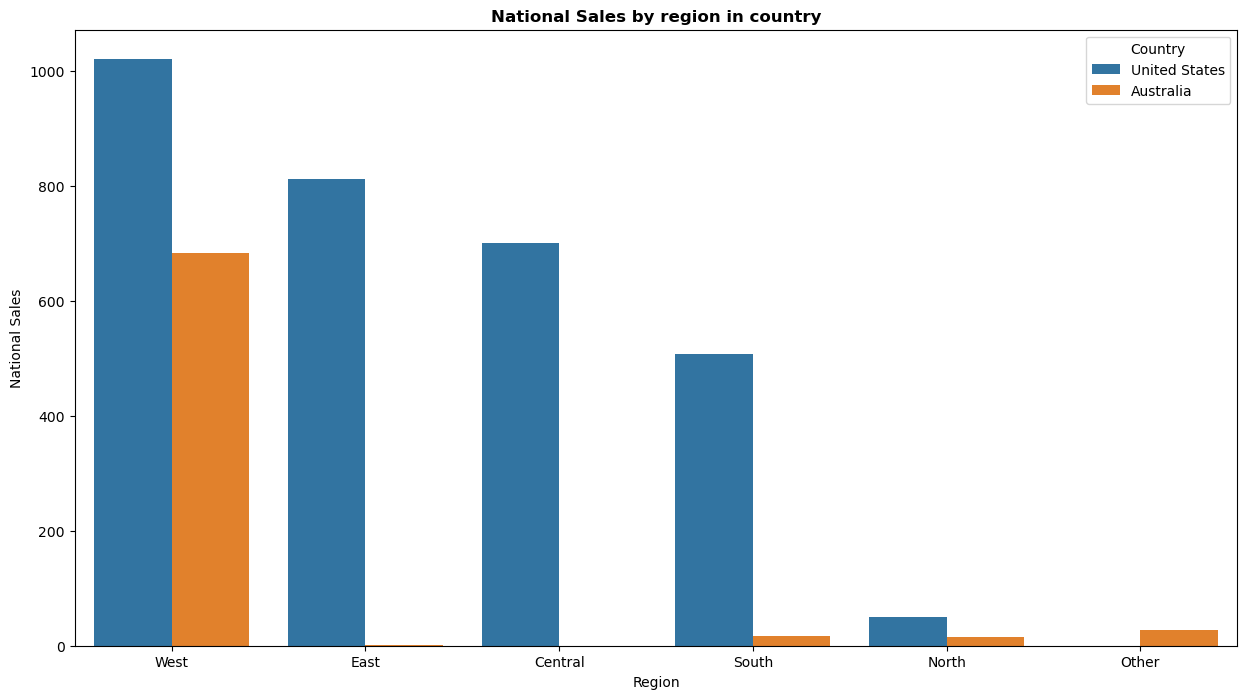

In [137]:
plt.figure(figsize=(15,8))
sns.barplot(data=National_Sales,x="Region",y="National Sales",hue="Country")
plt.title("National Sales by region in country", fontweight="bold")
plt.show()
